In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import scipy
import pickle
import math
import solvers
import sde
import dnnlib

torch.manual_seed(42)

In [13]:
with dnnlib.util.open_url("model/edm2-img64-xl-0671088-0.040.pkl") as f:
    data = pickle.load(f)
model = data["ema"].to("cuda")

In [14]:
encoder = data.get('encoder', None)
if encoder is None:
    encoder = dnnlib.util.construct_class_by_name(class_name='training.encoders.StandardRGBEncoder')

In [15]:
sigma_min = 0.002
sigma_max = 80

# sde_ = sde.EDMSDE().to("cuda")
sde_ = sde.VarianceExplodingEDMSDE(sigma_min, sigma_max).to("cuda")
rsde = sde_.get_reverse_sde(model).to("cuda")
rsde.ode = False

In [16]:
x = torch.zeros((16, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((1,)).to("cuda")
noise = sde_.sample_noise(x, t)[0]

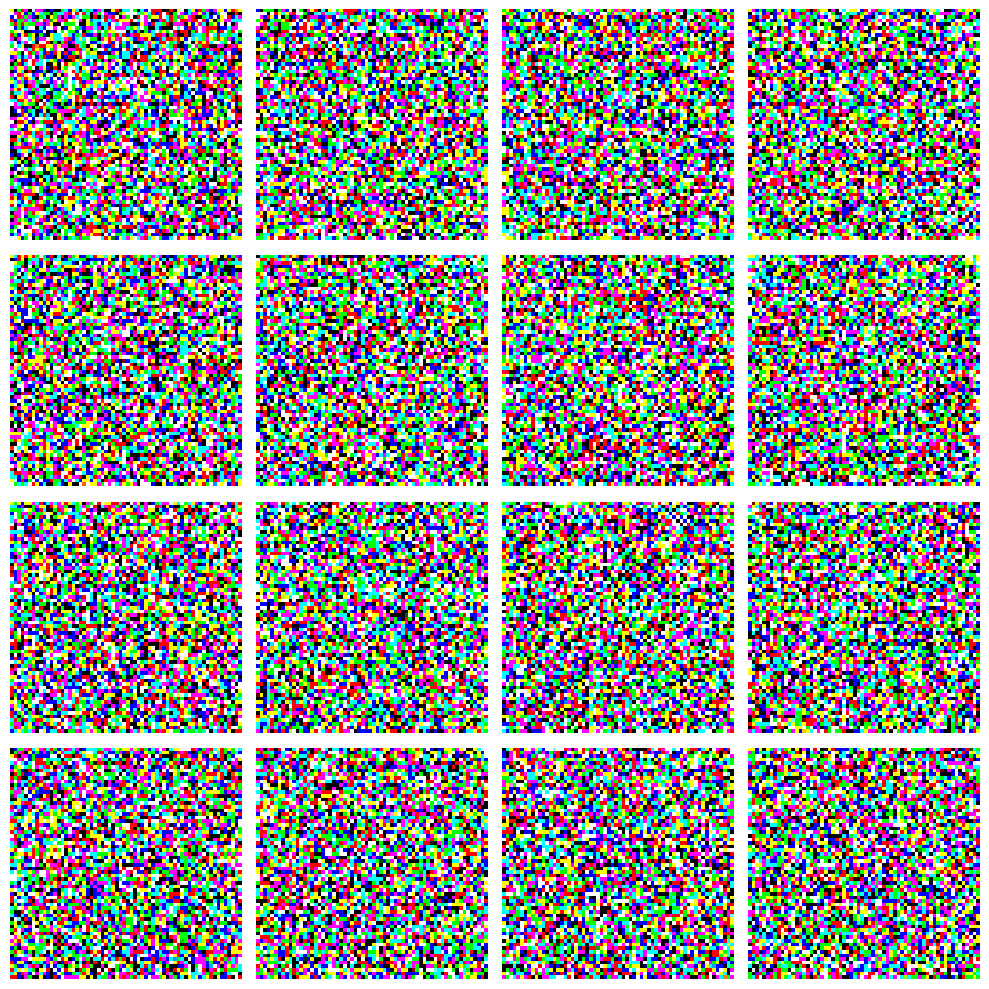

In [17]:
images = encoder.decode(noise).permute(0, 2, 3, 1)

def plot_images(images):
    fig, axes = plt.subplots(4, 4)
    fig.set_size_inches(10, 10)
    
    for i in range(4):
        for j in range(4):
            axes[i][j].imshow(images[i * 4 + j])
            axes[i][j].axis("off")
            
    fig.tight_layout()
    
plot_images(images.cpu())

In [18]:
n_steps = 718
rho = 7
# From EDM2 code
# step_indices = torch.arange(n_steps)
# sigma_steps = (sigma_max ** (1 / rho) + step_indices / (n_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
# discretisation = torch.cat([sigma_steps, torch.zeros_like(sigma_steps[:1])])
discretisation = torch.linspace(1, 0, n_steps)

em_solver = solvers.EulerMarayumaSolver(rsde, discretisation).to("cuda")

x_em = em_solver.solve(noise.clone())

tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(F

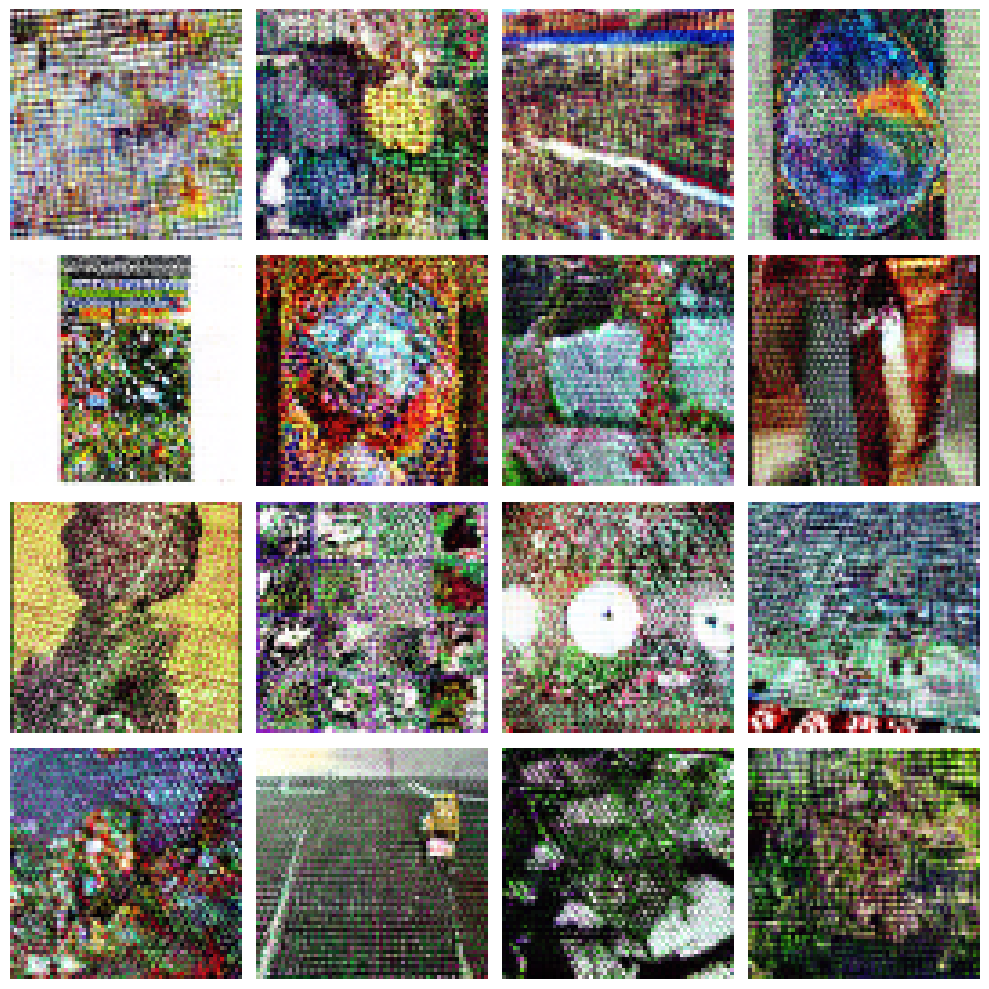

In [19]:
images = encoder.decode(x_em).permute(0, 2, 3, 1)

plot_images(images.cpu())

In [20]:
rsde.reset_nfe()

pi_solver = solvers.PISolver(
    rsde,
    ki=0.101, 
    kp=0.09, 
    tau=1, 
    alpha=0.5,
    h_start=0.0005,
    max_h=0.01,
    max_decrease=0.7,
    max_increase=1.3,
    timeout=1000,
    interval=(1, 0)
).to("cuda")

x_pi = pi_solver.solve(noise.clone())

T = 0.9994999766349792, h = -0.00047756804269738495
T = 0.9990224242210388, h = -0.00047298328718170524
T = 0.9985494017601013, h = -0.0004669195623137057
T = 0.9980825185775757, h = -0.00046229304280132055
T = 0.9976202249526978, h = -0.0004584997077472508
T = 0.9971617460250854, h = -0.00045564776519313455
T = 0.9967060685157776, h = -0.00045276631135493517
T = 0.996253252029419, h = -0.00045089676859788597
T = 0.9958024024963379, h = -0.0004493131418712437
T = 0.995353102684021, h = -0.0004481069918256253
T = 0.9949049949645996, h = -0.00044700392754748464
T = 0.9944579601287842, h = -0.00044651038479059935
T = 0.9940114617347717, h = -0.00044654757948592305
T = 0.9935649037361145, h = -0.00044658806291408837
T = 0.9931182861328125, h = -0.0004465535166673362
T = 0.9926717281341553, h = -0.0004473227891139686
T = 0.9922244548797607, h = -0.00044735241681337357
T = 0.9917770624160767, h = -0.0004479522758629173
T = 0.9913291335105896, h = -0.00044881069334223866
T = 0.990880370140075

In [21]:
rsde.nfe / 16

718.875

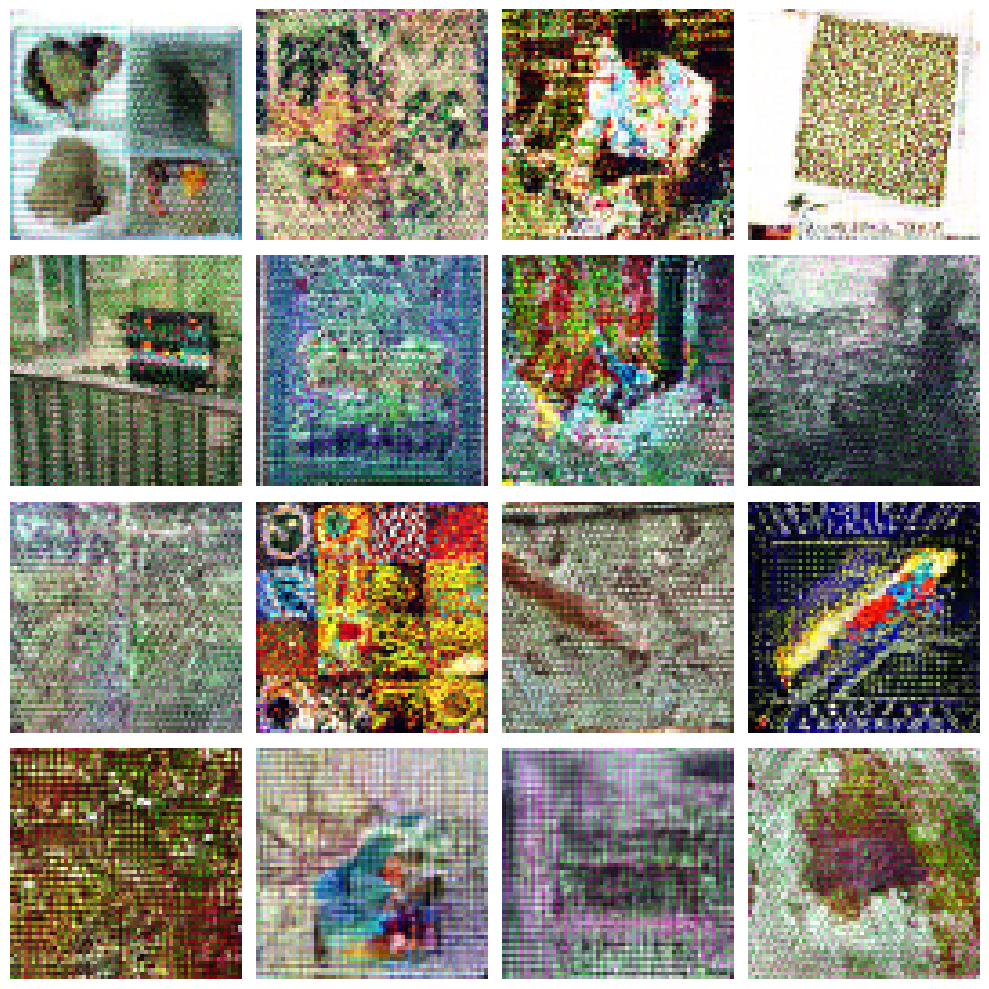

In [22]:
images = encoder.decode(x_pi).permute(0, 2, 3, 1)
plot_images(images.cpu())